# **IMPORT LIBRARY**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

print("Library siap.")

Library siap.


# **LOAD DATA**

In [2]:
USGS_URL = "https://raw.githubusercontent.com/SitiFadhilahRahmi/TB_VisdatSpasioTemporal_2311532003/main/cleandata/clean_usgs.csv"

df_gempa = pd.read_csv(USGS_URL)

print(f"Total gempa : {len(df_gempa):,}")

Total gempa : 11,938


# **DETEKSI ANOMALI**

In [3]:
# Fitur: magnitudo, kedalaman
df_gempa["is_shallow"] = (df_gempa["depth"] <= 70).astype(int)
features_gempa = ["mag", "is_shallow"]

scaler_gempa = StandardScaler()
X_gempa_scaled = scaler_gempa.fit_transform(df_gempa[features_gempa])

iso_gempa = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=200
)

df_gempa["anomaly_score"] = iso_gempa.fit_predict(X_gempa_scaled)
df_gempa["anomaly_score_raw"] = iso_gempa.decision_function(X_gempa_scaled)

df_gempa["is_anomaly"] = df_gempa["anomaly_score"] == -1

print(f"Total anomali terdeteksi: {df_gempa['is_anomaly'].sum()} dari {len(df_gempa)} ({df_gempa['is_anomaly'].mean()*100:.1f}%)")

Total anomali terdeteksi: 570 dari 11938 (4.8%)


# **VISUALISASI**

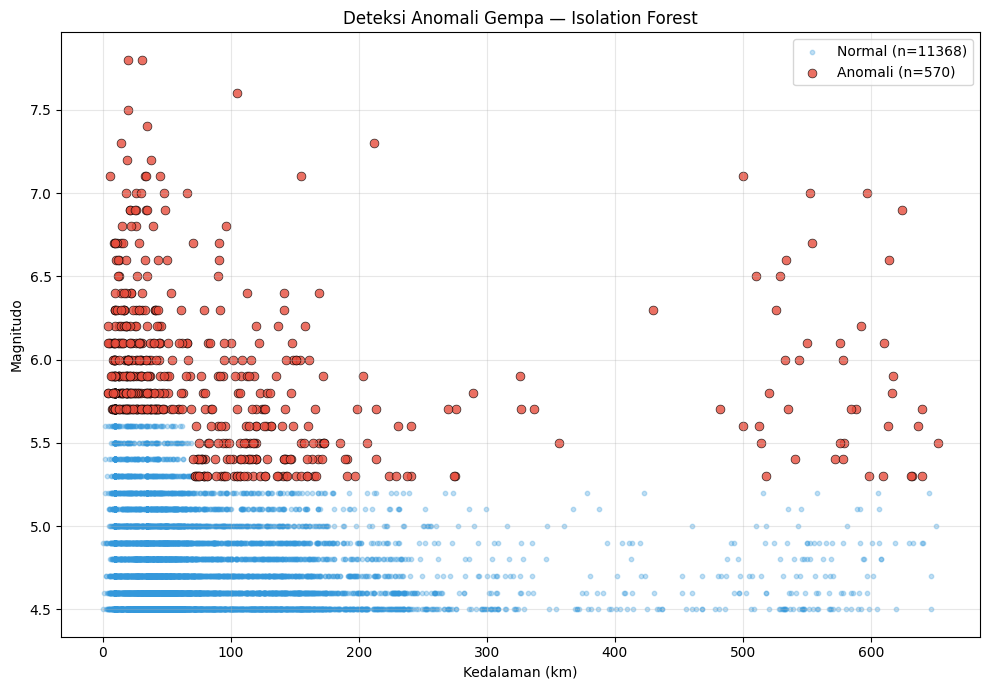

In [4]:
plt.figure(figsize=(10, 7))

normal = df_gempa[~df_gempa["is_anomaly"]]
anomaly = df_gempa[df_gempa["is_anomaly"]]

plt.scatter(normal["depth"], normal["mag"], s=10, alpha=0.3, color="#3498db", label=f"Normal (n={len(normal)})")
plt.scatter(anomaly["depth"], anomaly["mag"], s=40, alpha=0.8, color="#e74c3c", label=f"Anomali (n={len(anomaly)})", edgecolors="black", linewidths=0.5)

plt.xlabel("Kedalaman (km)")
plt.ylabel("Magnitudo")
plt.title("Deteksi Anomali Gempa — Isolation Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("anomaly_gempa_scatter.png", dpi=150)
plt.show()

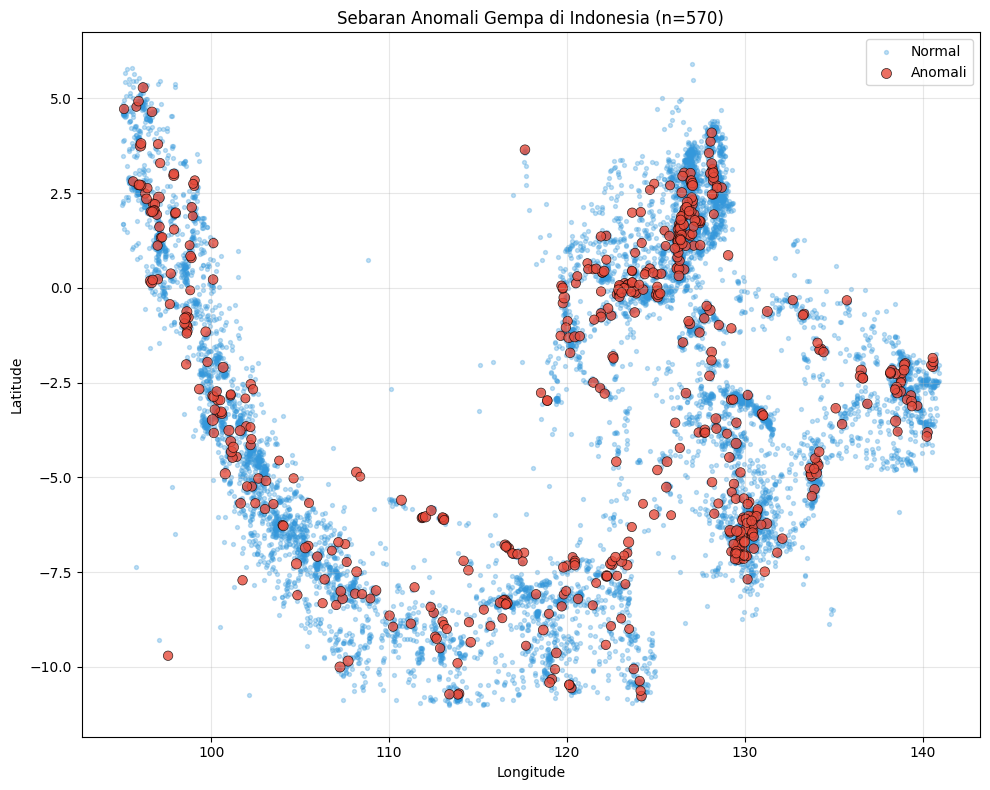

In [5]:
plt.figure(figsize=(10, 8))

plt.scatter(normal["longitude"], normal["latitude"], s=8, alpha=0.3, color="#3498db", label="Normal")
plt.scatter(anomaly["longitude"], anomaly["latitude"], s=anomaly["mag"]*8, alpha=0.8, color="#e74c3c", label="Anomali", edgecolors="black", linewidths=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Sebaran Anomali Gempa di Indonesia (n={len(anomaly)})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("anomaly_gempa_map.png", dpi=150)
plt.show()

# **HASIL**

In [6]:
print("RINGKASAN GEMPA")
print(df_gempa.groupby("is_anomaly")[["mag", "depth"]].agg(["mean", "min", "max"]))

RINGKASAN GEMPA
                 mag                 depth              
                mean  min  max        mean  min      max
is_anomaly                                              
False       4.747546  4.5  5.6   64.397537  0.3  650.655
True        5.899123  5.3  7.8  103.384430  4.0  652.530


In [7]:
OUTPUT_GEMPA  = "clean_usgs_anomaly.csv"

df_gempa.drop(columns=["anomaly_score"]).rename(
    columns={"anomaly_score_raw": "anomaly_score"}
).to_csv(OUTPUT_GEMPA, index=False)


print(f"Disimpan: {OUTPUT_GEMPA} ({len(df_gempa):,} rows)")
print(f"  Anomali: {df_gempa['is_anomaly'].sum()} ({df_gempa['is_anomaly'].mean()*100:.1f}%)")

Disimpan: clean_usgs_anomaly.csv (11,938 rows)
  Anomali: 570 (4.8%)


In [10]:
# **EVALUASI MODEL**
from sklearn.metrics import silhouette_score

# Silhouette Score - mengukur separasi cluster normal vs anomali
sil_score = silhouette_score(X_gempa_scaled, df_gempa["anomaly_score"])
print(f"Silhouette Score: {sil_score:.4f}")

if sil_score > 0.5:
    interpretasi = "Separasi kuat — anomali jelas terpisah dari data normal"
elif sil_score > 0.25:
    interpretasi = "Separasi sedang — anomali cukup terpisah, ada overlap"
elif sil_score > 0:
    interpretasi = "Separasi lemah — anomali tidak jelas beda dari normal"
else:
    interpretasi = "Tidak ada separasi — model gagal membedakan anomali dari normal"

print(f"Interpretasi: {interpretasi}")

Silhouette Score: 0.5787
Interpretasi: Separasi kuat — anomali jelas terpisah dari data normal
